In [1]:
#data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading datasets...")

matches = pd.read_csv("/content/matches_updated_ipl_upto_2025.csv")
deliveries = pd.read_csv("/content/deliveries_updated_ipl_upto_2025.csv")

print(f"Matches dataset loaded with shape: {matches.shape}")
print(f"Deliveries dataset loaded with shape: {deliveries.shape}")

Loading datasets...
Matches dataset loaded with shape: (1169, 28)
Deliveries dataset loaded with shape: (94685, 20)


In [2]:
print(deliveries.columns)
print(matches.columns)

Index(['matchId', 'inning', 'over_ball', 'over', 'ball', 'batting_team',
       'bowling_team', 'batsman', 'non_striker', 'bowler', 'batsman_runs',
       'extras', 'isWide', 'isNoBall', 'Byes', 'LegByes', 'Penalty',
       'dismissal_kind', 'player_dismissed', 'date'],
      dtype='object')
Index(['season', 'venue', 'event', 'winner_runs', 'umpire2', 'toss_winner',
       'date', 'neutralvenue', 'umpire1', 'city', 'reserve_umpire', 'winner',
       'eliminator', 'date1', 'method', 'team1', 'toss_decision', 'gender',
       'team2', 'balls_per_over', 'winner_wickets', 'tv_umpire',
       'player_of_match', 'match_referee', 'outcome', 'date2', 'match_number',
       'matchId'],
      dtype='object')


In [3]:
print("Standardizing column names.")

matches.columns = matches.columns.str.lower().str.strip()
deliveries.columns = deliveries.columns.str.lower().str.strip()

print("Inspecting schema and data types")

print("\nMatches info:")
print(matches.info())

print("\nDeliveries info:")
print(deliveries.info())

Standardizing column names.
Inspecting schema and data types

Matches info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season           1169 non-null   object 
 1   venue            1169 non-null   object 
 2   event            1169 non-null   object 
 3   winner_runs      531 non-null    float64
 4   umpire2          1169 non-null   object 
 5   toss_winner      1169 non-null   object 
 6   date             1169 non-null   object 
 7   neutralvenue     77 non-null     object 
 8   umpire1          1169 non-null   object 
 9   city             1118 non-null   object 
 10  reserve_umpire   1145 non-null   object 
 11  winner           1146 non-null   object 
 12  eliminator       15 non-null     object 
 13  date1            2 non-null      object 
 14  method           19 non-null     object 
 15  team1            1169 non-null

In [4]:
print("Missing value analysis")

print("\nMissing values in matches (top 15):")
print(matches.isna().sum().sort_values(ascending=False).head(15))

print("\nMissing values in deliveries (top 15):")
print(deliveries.isna().sum().sort_values(ascending=False).head(15))


Missing value analysis

Missing values in matches (top 15):
date2              1167
date1              1167
eliminator         1154
method             1150
outcome            1146
neutralvenue       1092
winner_runs         638
winner_wickets      554
match_number         70
city                 51
reserve_umpire       24
winner               23
player_of_match       8
tv_umpire             4
toss_winner           0
dtype: int64

Missing values in deliveries (top 15):
penalty             94684
byes                94401
isnoball            94261
legbyes             93034
iswide              91808
dismissal_kind      89984
player_dismissed    89984
batsman_runs            1
extras                  1
bowler                  1
date                    1
matchid                 0
over                    0
over_ball               0
inning                  0
dtype: int64


In [5]:
print("Dropping columns with no impact on player performance")

MATCH_DROP_COLS = [
    "umpire1", "umpire2", "tv_umpire",
    "reserve_umpire", "match_referee",
    "outcome", "method","team1", "team2",
    "date1", "date2", "event"
]

before_cols = matches.shape[1]
matches.drop(columns=[c for c in MATCH_DROP_COLS if c in matches.columns],
             inplace=True)
after_cols = matches.shape[1]

print(f"Dropped {before_cols - after_cols} columns from matches dataset.")
print("Remaining columns:", list(matches.columns))

Dropping columns with no impact on player performance
Dropped 12 columns from matches dataset.
Remaining columns: ['season', 'venue', 'winner_runs', 'toss_winner', 'date', 'neutralvenue', 'city', 'winner', 'eliminator', 'toss_decision', 'gender', 'balls_per_over', 'winner_wickets', 'player_of_match', 'match_number', 'matchid']


In [7]:
print("Converting date columns to datetime")

matches["date"] = pd.to_datetime(matches["date"], errors="coerce")
deliveries["date"] = pd.to_datetime(deliveries["date"], errors="coerce")

print("Date conversion completed.")
print("Matches dataset info:")
print(matches.info())
print("Deliveries dataset info:")
print(deliveries.info())

Converting date columns to datetime
Date conversion completed.
Matches dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   season           1169 non-null   object        
 1   venue            1169 non-null   object        
 2   winner_runs      531 non-null    float64       
 3   toss_winner      1169 non-null   object        
 4   date             1169 non-null   datetime64[ns]
 5   neutralvenue     77 non-null     object        
 6   city             1118 non-null   object        
 7   winner           1146 non-null   object        
 8   eliminator       15 non-null     object        
 9   toss_decision    1169 non-null   object        
 10  gender           1169 non-null   object        
 11  balls_per_over   1169 non-null   int64         
 12  winner_wickets   615 non-null    float64       
 13  player_o

In [8]:
print("Cleaning numeric delivery-level columns")

NUM_COLS = [
    "batsman_runs", "extras",
    "iswide", "isnoball",
    "byes", "legbyes", "penalty"
]

deliveries[NUM_COLS] = deliveries[NUM_COLS].fillna(0).astype(int)

print("Numeric missing values filled with 0 and cast to int.")

Cleaning numeric delivery-level columns
Numeric missing values filled with 0 and cast to int.


In [10]:
print("Cleaning categorical columns")

deliveries["dismissal_kind"] = deliveries["dismissal_kind"].fillna("not_out")
deliveries["player_dismissed"] = deliveries["player_dismissed"].fillna("None")

matches["neutralvenue"] = matches["neutralvenue"].fillna(0)
matches["eliminator"] = matches["eliminator"].fillna("N")

print("Categorical missing values handled.")

print("\nNull values after cleaning (deliveries):")
print(deliveries[["dismissal_kind", "player_dismissed"]].isnull().sum())

print("\nNull values after cleaning (matches):")
print(matches[["neutralvenue", "eliminator"]].isnull().sum())

Cleaning categorical columns
Categorical missing values handled.

Null values after cleaning (deliveries):
dismissal_kind      0
player_dismissed    0
dtype: int64

Null values after cleaning (matches):
neutralvenue    0
eliminator      0
dtype: int64


In [12]:
print("Merging match-level context into deliveries...")

CONTEXT_COLS = [
    "matchid", "season", "venue", "city",
    "toss_winner", "toss_decision",
    "winner", "winner_runs", "winner_wickets",
    "neutralvenue", "eliminator", "player_of_match"
]

df = deliveries.merge(
    matches[CONTEXT_COLS],
    on="matchid",
    how="left",
    validate="many_to_one"
)
print("Merged dataset shape:", df.shape)
df.sample(5)

Merging match-level context into deliveries...
Merged dataset shape: (94685, 31)


,matchid,inning,over_ball,over,ball,batting_team,bowling_team,batsman,non_striker,bowler,...,venue,city,toss_winner,toss_decision,winner,winner_runs,winner_wickets,neutralvenue,eliminator,player_of_match
82156,598020,2,14.6,14,6,Delhi Daredevils,Chennai Super Kings,KM Jadhav,M Morkel,RA Jadeja,...,Feroz Shah Kotla,Delhi,Chennai Super Kings,bat,Chennai Super Kings,86.0,NaN,0,N,MEK Hussey
90534,598056,2,15.5,15,5,Kings XI Punjab,Sunrisers Hyderabad,LA Pomersbach,R Sathish,NLTC Perera,...,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Kings XI Punjab,field,Sunrisers Hyderabad,30.0,NaN,0,N,PA Patel
32474,419127,1,6.6,6,6,Kolkata Knight Riders,Kings XI Punjab,MK Tiwary,SC Ganguly,PP Chawla,...,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Kolkata Knight Riders,bat,Kolkata Knight Riders,39.0,NaN,0,N,MK Tiwary
20050,392210,2,18.1,18,1,Kings XI Punjab,Rajasthan Royals,Yuvraj Singh,RR Powar,A Singh,...,Kingsmead,Durban,Kings XI Punjab,field,Rajasthan Royals,78.0,NaN,True,N,GC Smith
70880,548360,1,7.7,7,7,Mumbai Indians,Royal Challengers Bangalore,SR Tendulkar,KD Karthik,J Syed Mohammad,...,Wankhede Stadium,Mumbai,Royal Challengers Bangalore,field,Royal Challengers Bangalore,NaN,9.0,0,N,CH Gayle


In [13]:
print("Creating total runs scored by each batsman")

# Group by batsman and sum runs
total_runs = (
    deliveries
    .groupby("batsman", as_index=False)["batsman_runs"]
    .sum()
    .rename(columns={"batsman_runs": "total_runs"})
)

print(f"Number of unique batsmen: {total_runs.shape[0]}")
total_runs.head(10)

Creating total runs scored by each batsman
Number of unique batsmen: 372


,batsman,total_runs
0,A Ashish Reddy,160
1,A Chandila,4
2,A Chopra,53
3,A Flintoff,62
4,A Kumble,35
5,A Mishra,275
6,A Mithun,34
7,A Mukund,19
8,A Nehra,39
9,A Singh,2



Top 10 Batsmen by Total Runs:


,batsman,total_runs
302,SK Raina,2810
68,CH Gayle,2537
258,RG Sharma,2513
109,G Gambhir,2471
140,JH Kallis,2348
314,SR Tendulkar,2334
347,V Kohli,2278
205,MS Dhoni,2244
247,R Dravid,2174
349,V Sehwag,2174


/tmp/ipython-input-2188147326.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_runs', y='batsman', data=top_10_batsmen, palette='viridis')


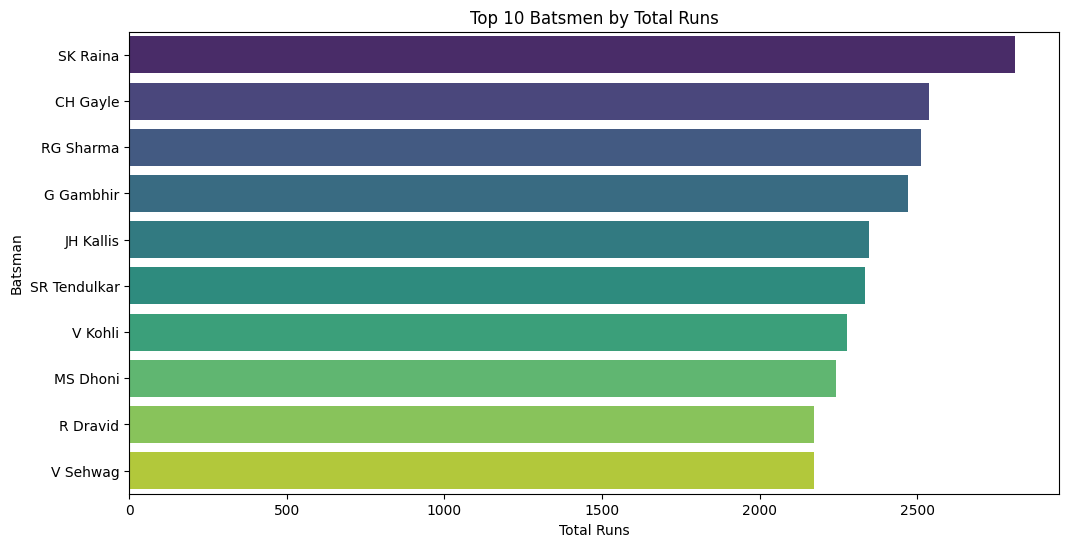

In [14]:
# Sort batsmen by total runs and display top 10
top_10_batsmen = total_runs.sort_values(by='total_runs', ascending=False).head(10)
print("\nTop 10 Batsmen by Total Runs:")
display(top_10_batsmen)

# Visualize top 10 batsmen
plt.figure(figsize=(12, 6))
sns.barplot(x='total_runs', y='batsman', data=top_10_batsmen, palette='viridis')
plt.title('Top 10 Batsmen by Total Runs')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.show()

In [15]:
import os

print("saving clean dataset")
os.makedirs('outputs', exist_ok=True)

df.to_csv("outputs/clean_ball_by_ball.csv", index=False)

print("Saved file: outputs/clean_ball_by_ball.csv")

saving clean dataset
Saved file: outputs/clean_ball_by_ball.csv


In [ ]:
#converting to lower case
matches.columns = matches.columns.str.lower().str.strip()
deliveries.columns = deliveries.columns.str.lower().str.strip()

#merging the data
df = deliveries.merge(
    matches,
    on="matchid",
    how="left",
    validate="many_to_one"
)

#dropping the unnecessary columns
df = df.drop(columns=["date_y","umpire1","umpire2","reserve_umpire","team1","team2","tv_umpire", "date1", "date2"], errors="ignore")


df["date"] = pd.to_datetime(df["date_x"], errors="coerce")

#sorting the data
df = df.sort_values(['date', 'matchid', 'inning', 'over', 'ball']).reset_index(drop=True)



In [ ]:
print(matches.columns)

Index(['season', 'venue', 'event', 'winner_runs', 'umpire2', 'toss_winner',
       'date', 'neutralvenue', 'umpire1', 'city', 'reserve_umpire', 'winner',
       'eliminator', 'date1', 'method', 'team1', 'toss_decision', 'gender',
       'team2', 'balls_per_over', 'winner_wickets', 'tv_umpire',
       'player_of_match', 'match_referee', 'outcome', 'date2', 'match_number',
       'matchId'],
      dtype='object')


In [ ]:
print(deliveries.columns)

Index(['matchId', 'inning', 'over_ball', 'over', 'ball', 'batting_team',
       'bowling_team', 'batsman', 'non_striker', 'bowler', 'batsman_runs',
       'extras', 'isWide', 'isNoBall', 'Byes', 'LegByes', 'Penalty',
       'dismissal_kind', 'player_dismissed', 'date'],
      dtype='object')


In [ ]:
deliveries = deliveries.rename(columns={
    "matchId": "match_id",
    "batsman": "striker",
    "batsman_runs": "runs_off_bat",
    "isWide": "wide",
    "isNoBall": "noball",
    "Byes": "byes",
    "LegByes": "legbyes",
    "Penalty": "penalty",
    "dismissal_kind": "wicket_type"
})

In [ ]:
matches = matches.rename(columns={
    "matchId": "match_id"
})

In [ ]:
num_cols = [
    "runs_off_bat", "extras", "wide", "noball",
    "byes", "legbyes", "penalty"
]
deliveries[num_cols] = deliveries[num_cols].fillna(0).astype(int)

In [ ]:
deliveries.duplicated(
    subset=["match_id", "inning", "over", "ball"]
).sum()

deliveries = deliveries.drop_duplicates(
    subset=["match_id", "inning", "over", "ball"],
    keep="first"
)

In [ ]:
deliveries = deliveries.drop(
    columns=["penalty", "byes", "legbyes", "date"]
)

In [ ]:
matches = matches.drop(columns=[
    "winner", "outcome", "winner_runs", "winner_wickets",
    "player_of_match", "umpire1", "umpire2", "tv_umpire",
    "reserve_umpire", "match_referee", "event", "method",
    "toss_decision", "toss_winner", "date1", "date2"
])

In [ ]:
matches_keep = matches[
    ["match_id", "season", "venue", "city",
     "team1", "team2", "neutralvenue"]
]

In [ ]:
df = deliveries.merge(
    matches_keep,
    on="match_id",
    how="left"
)

In [ ]:
df = df.drop(columns=["team1", "team2"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278170 entries, 0 to 278169
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   match_id          278170 non-null  int64  
 1   inning            278170 non-null  int64  
 2   over_ball         278170 non-null  float64
 3   over              278170 non-null  int64  
 4   ball              278170 non-null  int64  
 5   batting_team      278170 non-null  object 
 6   bowling_team      278170 non-null  object 
 7   striker           278170 non-null  object 
 8   non_striker       278170 non-null  object 
 9   bowler            278170 non-null  object 
 10  runs_off_bat      278170 non-null  int64  
 11  extras            278170 non-null  int64  
 12  wide              278170 non-null  int64  
 13  noball            278170 non-null  int64  
 14  wicket_type       13822 non-null   object 
 15  player_dismissed  13822 non-null   object 
 16  season            27

In [ ]:
df.isna().sum()

,0
match_id,0
inning,0
over_ball,0
over,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0
bowler,0


In [ ]:
df["is_wicket"] = df["player_dismissed"].notna().astype(int)

In [ ]:
df["city"] = df["city"].fillna("Unknown")
df["neutralvenue"] = df["neutralvenue"].fillna(0).astype(int)

In [ ]:
bowler_wicket_types = [
    "bowled", "caught", "lbw", "stumped", "caught and bowled", "hit wicket"
]

df["is_bowler_wicket"] = (
    df["wicket_type"].isin(bowler_wicket_types)
).astype(int)

In [ ]:
# Select object (string) columns
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    print(f"\nColumn: {col}")
    print(f"Unique count: {df[col].nunique()}")
    print("Sample unique values:")
    print(df[col].dropna().unique()[:20])  # show first 20


Column: batting_team
Unique count: 19
Sample unique values:
['Kolkata Knight Riders' 'Royal Challengers Bangalore'
 'Chennai Super Kings' 'Kings XI Punjab' 'Rajasthan Royals'
 'Delhi Daredevils' 'Mumbai Indians' 'Deccan Chargers'
 'Kochi Tuskers Kerala' 'Pune Warriors' 'Sunrisers Hyderabad'
 'Rising Pune Supergiants' 'Gujarat Lions' 'Rising Pune Supergiant'
 'Delhi Capitals' 'Punjab Kings' 'Lucknow Super Giants' 'Gujarat Titans'
 'Royal Challengers Bengaluru']

Column: bowling_team
Unique count: 19
Sample unique values:
['Royal Challengers Bangalore' 'Kolkata Knight Riders' 'Kings XI Punjab'
 'Chennai Super Kings' 'Delhi Daredevils' 'Rajasthan Royals'
 'Mumbai Indians' 'Deccan Chargers' 'Kochi Tuskers Kerala' 'Pune Warriors'
 'Sunrisers Hyderabad' 'Rising Pune Supergiants' 'Gujarat Lions'
 'Rising Pune Supergiant' 'Delhi Capitals' 'Punjab Kings' 'Gujarat Titans'
 'Lucknow Super Giants' 'Royal Challengers Bengaluru']

Column: striker
Unique count: 704
Sample unique values:
['SC Ganguly

<Axes: xlabel='runs_off_bat'>

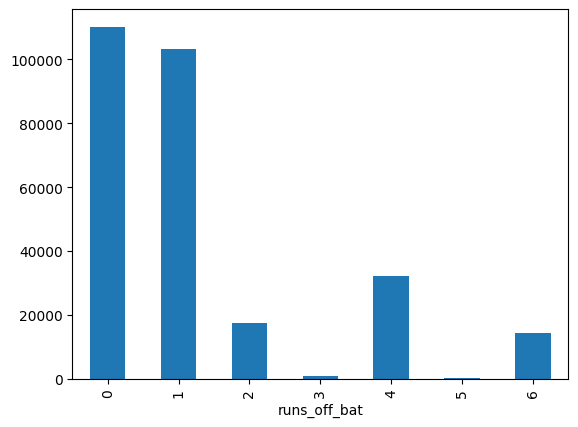

In [ ]:
df["runs_off_bat"].value_counts().sort_index().plot(kind="bar")

In [ ]:
df["is_wicket"] = df["player_dismissed"].notna().astype(int)

df["is_wicket"].value_counts(normalize=True)

df["wicket_type"].value_counts()

,count
wicket_type,
caught,8664
bowled,2345
run out,1153
lbw,853
caught and bowled,388
stumped,376
hit wicket,18
retired hurt,17
retired out,5


In [ ]:
df.groupby("venue")["runs_off_bat"].mean().sort_values(ascending=False).sample(10)

,runs_off_bat
venue,
"Vidarbha Cricket Association Stadium, Jamtha",1.103914
Feroz Shah Kotla,1.254409
Eden Gardens,1.247665
"Rajiv Gandhi International Stadium, Uppal, Hyderabad",1.477645
Arun Jaitley Stadium,1.296484
"Himachal Pradesh Cricket Association Stadium, Dharamsala",1.536210
M Chinnaswamy Stadium,1.283663
"Sawai Mansingh Stadium, Jaipur",1.442384
"Punjab Cricket Association IS Bindra Stadium, Mohali",1.327117


In [ ]:
df.groupby("venue")["is_bowler_wicket"].mean().sort_values(ascending=False).head(10)

,is_bowler_wicket
venue,
"Vidarbha Cricket Association Stadium, Jamtha",0.058030
"Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur",0.057958
"Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam",0.057113
Newlands,0.053281
"Maharashtra Cricket Association Stadium, Pune",0.051282
"Himachal Pradesh Cricket Association Stadium, Dharamsala",0.050847
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium,0.050708
"MA Chidambaram Stadium, Chepauk, Chennai",0.049885
Dr DY Patil Sports Academy,0.049837


In [ ]:
player_matches = df.groupby("striker")["match_id"].nunique()

player_matches.describe()

,match_id
count,704.000000
mean,25.052557
std,40.288488
min,1.000000
25%,3.000000
50%,8.500000
75%,27.000000
max,266.000000


<Axes: >

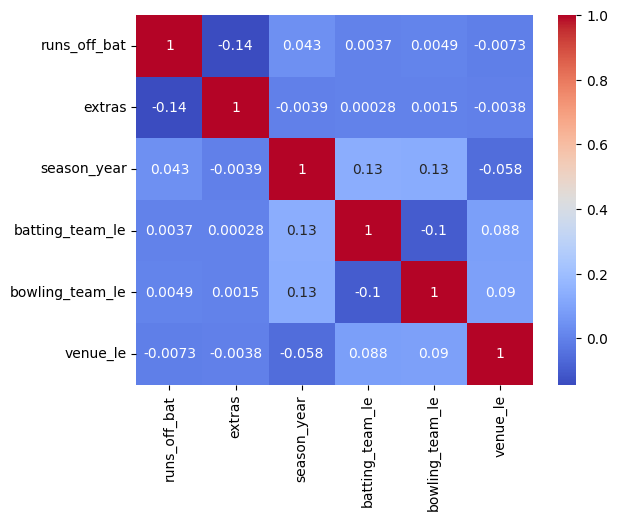

In [ ]:
eda_cols = [
    "runs_off_bat",
    "extras",
    "season_year",
    "batting_team_le",
    "bowling_team_le",
    "venue_le"
]

sns.heatmap(eda_df[eda_cols].corr(), annot=True, cmap="coolwarm")


In [ ]:
team_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
}

for col in ["batting_team", "bowling_team"]:
    df[col] = df[col].replace(team_map)